In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetic_data.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (101766, 50)

Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df = df.replace('?', pd.NA)

df = df.dropna(thresh=len(df)*0.5, axis=1)

cols_needed = [
    'race', 'gender', 'age', 'admission_type_id',
    'time_in_hospital', 'num_medications', 'num_procedures',
    'number_inpatient', 'number_diagnoses', 'readmitted'
]
df = df[cols_needed]

df['readmitted_30days'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print("Cleaned shape:", df.shape)
print("\nReadmission breakdown:\n", df['readmitted'].value_counts())

Cleaned shape: (101766, 11)

Readmission breakdown:
 readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [4]:
# Overall 30-day readmission rate
rate = df['readmitted_30days'].mean() * 100
print(f"Overall 30-day readmission rate: {rate:.1f}%")

# Readmission rate by age group
age_readmit = df.groupby('age')['readmitted_30days'].mean().sort_values(ascending=False) * 100
print("\nReadmission rate by age group:\n", age_readmit.round(1))

Overall 30-day readmission rate: 11.2%

Readmission rate by age group:
 age
[20-30)     14.2
[80-90)     12.1
[70-80)     11.8
[30-40)     11.2
[60-70)     11.1
[90-100)    11.1
[40-50)     10.6
[50-60)      9.7
[10-20)      5.8
[0-10)       1.9
Name: readmitted_30days, dtype: float64


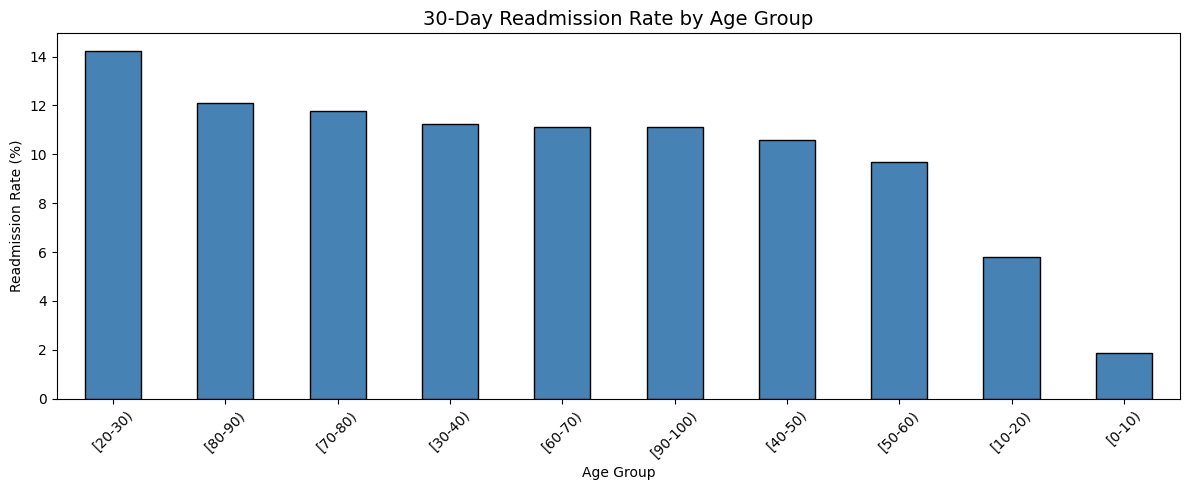

In [5]:
plt.figure(figsize=(12, 5))
age_readmit.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('30-Day Readmission Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('readmission_by_age.png')
plt.show()

In [7]:
#Creating a clean summary table for Power BI
summary = df.groupby(['age', 'race', 'gender']).agg(
    total_patients=('readmitted_30days', 'count'),
    readmitted_30days=('readmitted_30days', 'sum'),
    avg_time_in_hospital=('time_in_hospital', 'mean'),
    avg_medications=('num_medications', 'mean')
).reset_index()

summary['readmission_rate_pct'] = (summary['readmitted_30days'] / summary['total_patients'] * 100).round(1)
summary.to_csv('readmissions_summary.csv', index=False)
print("Exported! Download readmissions_summary.csv")

Exported! Download readmissions_summary.csv
